In [2]:
# Load packages
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
from scipy.sparse import issparse

In [3]:
# Load data
data_dir = '../data/frangieh/'
adata = sc.read_h5ad(data_dir + 'adata_preprocessed.h5ad')

In [ ]:
adata.obs['perturbation'].value_counts()

KeyError: ('perturbation', 'condition')

In [6]:
# Feature Selection
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Save the HVG names
shared_hvgs = adata.var_names[adata.var["highly_variable"]]
print("Number of shared HVGs:", len(shared_hvgs))

Number of shared HVGs: 2000


In [8]:
# split data by condition
adata_control = adata[adata.obs['condition'] == 'Control']
adata_ifng = adata[adata.obs['condition'] == 'IFNγ']
adata_coculture = adata[adata.obs['condition'] == 'Co-culture']

adata_control_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Control",
    shared_hvgs
].copy()

adata_ifng_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "IFNγ",
    shared_hvgs
].copy()

adata_coculture_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Co-culture",
    shared_hvgs
].copy()

In [ ]:
all_data = {"control": adata_control, "ifng": adata_ifng, "coculture": adata_coculture}

## Pseudobulk and compute log fold change

In [ ]:
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control',
    min_cells: int = 5,
    pseudocount: float = 1e-6,
    data_type: str = 'counts',
) -> ad.AnnData:
    """
    Computes pseudobulk log2 fold changes (LFC) per perturbation relative to controls within each condition.
    
    Parameters
    ----------
    adata : ad.AnnData
        Single-cell AnnData object (log1p normalized or raw counts in .X).
    cond_key : str
        Observation key for experimental conditions (e.g., 'Control', 'IFNγ', 'Co-culture').
    pert_key : str
        Observation key for perturbation target labels.
    control_label : str
        Label indicating unperturbed control cells within pert_key.
    min_cells : int
        Minimum number of cells required per perturbation group to keep it.
    pseudocount : float
        Small offset added to linear means to prevent zero-division in log2 ratio.
    data_type : str
        Either 'counts' or 'log1p'. Specifies the type of data in adata.X.

    Returns
    -------
    ad.AnnData
        Pseudobulk AnnData object containing Log2 Fold Changes in .X,
        retained perturbation/condition metadata in .obs, and gene annotations in .var.
    """

    # 1. Clean up labels
    obs_df = adata.obs.copy()
    obs_df[pert_key] = obs_df[pert_key].astype(str).str.strip().str.lower()
    ctrl_label_clean = str(control_label).strip().lower()

    # 2. Filter perturbations with fewer than min_dataset_cells across the entire dataset
    if min_cells > 0:
        dataset_counts = obs_df[pert_key].value_counts()
        valid_dataset_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index
        cell_mask = obs_df[pert_key].isin(valid_dataset_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df[cell_mask].copy()
    else:
        adata_filtered = adata.copy()
    
    # 3. Extract expression matrix (linearize if log1p) or use raw counts
    if data_type == "log1p":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.expm1(X_linear.data)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.expm1(
                np.asarray(adata_filtered.X, dtype=np.float64)
            )
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    elif data_type == "counts":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.asarray(adata_filtered.X, dtype=np.float64)
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    else:
        X_linear = adata_filtered.X.copy()

    lfc_matrices = []
    obs_metadata_list = []

    # 4. Process each condition independently without per-condition min_cells filtering
    for cond_val, cond_obs in obs_df.groupby(cond_key):
        cond_indices = cond_obs.index
        cond_mask = obs_df.index.isin(cond_indices)

        # Extract linear matrix subset for this condition
        X_cond = X_linear[cond_mask, :]
        cond_perts = obs_df.loc[cond_indices, pert_key].values
        pert_counts_in_cond = cond_obs[pert_key].value_counts()

        # Locate control cells in this condition
        ctrl_mask = cond_perts == ctrl_label_clean
        if not np.any(ctrl_mask):
            print(
                f"Skipping condition '{cond_val}': No control cells"
                f" ('{ctrl_label_clean}') found."
            )
            continue

        # Compute mean linear profile for control
        if issparse(X_cond):
            ctrl_mean = np.asarray(X_cond[ctrl_mask, :].mean(axis=0)).ravel()
        else:
            ctrl_mean = X_cond[ctrl_mask, :].mean(axis=0)

        # Target all non-control perturbations present in this condition
        target_perts = [
            p for p in np.unique(cond_perts) if p != ctrl_label_clean
        ]

        cond_lfc_list = []
        retained_obs = []

        for pert in target_perts:
            p_mask = cond_perts == pert

            if issparse(X_cond):
                p_mean = np.asarray(X_cond[p_mask, :].mean(axis=0)).ravel()
            else:
                p_mean = X_cond[p_mask, :].mean(axis=0)

            # Calculate standard Log2 Fold Change
            lfc = np.log2((p_mean + pseudocount) / (ctrl_mean + pseudocount))
            cond_lfc_list.append(lfc)

            # Metadata tracking
            sample_obs_row = cond_obs[
                cond_obs[pert_key] == pert
            ].iloc[0].to_dict()
            sample_obs_row["n_cells_pseudobulk"] = pert_counts_in_cond[pert]
            retained_obs.append(sample_obs_row)

        if len(cond_lfc_list) > 0:
            lfc_matrices.append(np.vstack(cond_lfc_list))
            obs_metadata_list.extend(retained_obs)

    if not lfc_matrices:
        raise ValueError(
            "No valid perturbation groups could be computed across conditions."
        )

    # 5. Concatenate and return AnnData
    final_lfc_matrix = np.vstack(lfc_matrices)
    final_obs_df = pd.DataFrame(obs_metadata_list)
    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}" for row in obs_metadata_list
    ]

    lfc_adata = ad.AnnData(
        X=final_lfc_matrix, obs=final_obs_df, var=adata_filtered.var.copy()
    )
    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount

    return lfc_adata

In [9]:
adata_hvg_lfc = compute_pseudobulk_lfc(
    adata=adata_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=20,
    pseudocount=1e-6,
    x_is_log1p=True
)

In [12]:
adata_hvg_lfc

AnnData object with n_obs × n_vars = 705 × 2000
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'n_cells_pseudobulk'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_c

## Select Pertrubations and Test/Train Split

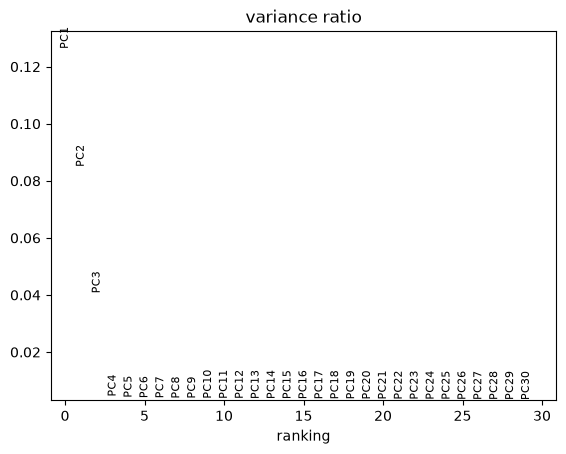

In [13]:
# Compute PCA
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(adata_hvg_lfc, n_comps=30)
sc.pl.pca_variance_ratio(adata_hvg_lfc, n_pcs=30, log=False)

In [15]:
sc.pp.pca(adata_hvg_lfc, n_comps=4)

In [17]:
adata_hvg_lfc.obs["perturbation"].value_counts()

perturbation
ifngr2      3
jak2        3
jak1        3
b2m         3
cd58        3
           ..
prelid3b    2
ahcy        2
farsa       2
ruvbl2      1
atp1a1      1
Name: count, Length: 238, dtype: int64

## Predict the log2 fold change

In [ ]:
# Task: Predict log2 fold changes for perturbations
#
# INPUT:
#
# OUTPUT:
#   Mean log2 fold-change profile across 2,000 genes
#
# DATA SPLIT:
#   40 unique perturbations for training
#   10 unique perturbations for testing